# SDC Testing Challenge — Test Prioritization

Welcome to the **Self-Driving Car (SDC) Testing Challenge**.

Your job is to **decide the order** in which a set of simulator-based driving tests should be executed, so that **failing tests (the car drives off the lane) appear as early as possible**. The earlier you find failures, the less simulation time is wasted before a problem is discovered.

This challenge mirrors the **2026 ICST/SBFT SDC Testing Tool Competition** ([info](https://conf.researchr.org/track/icst-2026/icst-2026-tool-competition--self-driving-car-testing) · [repo](https://github.com/christianbirchler-org/sdc-testing-competition)). The algorithmic task and evaluation metric are identical; only the packaging (gRPC + Docker + simulator DB) has been replaced with a local Python notebook.

Read the companion document `../1_challenge_guide.md` first — it explains the background and metrics in more depth.

## 1. Setup

You are given **two public files**:

- **`train_oracles`** (`data/sdc-train.json`) — test cases **with** their ground-truth label (`has_failed`). You may use these to learn patterns. This is what `initialize()` receives.
- **`test_suite`** (`data/sdc-test-suite.json`) — test cases **without** labels. This is what your prioritizer must reorder, and it is your real **submission target**.

The labels for the `test_suite` cases are **held by your instructor and are not in this repository**. To estimate your APFD while you develop, we carve a **local validation split** out of the labelled training set:

- **`dev_oracles`** — train on this.
- **`val_suite`** / **`val_ground_truth`** — reorder this and score against it (labels come from the training data, so this is fair game).

Your official score is computed by the evaluator on the hidden test set when you submit (Section 7).

In [1]:
import sys
from pathlib import Path

# Make `sdc_lib` importable from inside the exercises/ folder
CHALLENGE_ROOT = Path.cwd().parent
sys.path.insert(0, str(CHALLENGE_ROOT))

from sdc_lib import (
    load_train, load_test_suite, make_local_validation,
    evaluate,
    RandomPrioritizer, IdentityPrioritizer,
    plot_road, plot_roads_grid, plot_fault_detection_curve, plot_top_picks,
)

# PUBLIC data — the only files you have.
#   train_oracles : labelled cases   -> MyPrioritizer.initialize()
#   test_suite    : UNlabelled cases -> MyPrioritizer.prioritize()  (submission target)
train_oracles = load_train(CHALLENGE_ROOT / "data" / "sdc-train.json")
test_suite    = load_test_suite(CHALLENGE_ROOT / "data" / "sdc-test-suite.json")

# The test-set labels live with your instructor, not in this repo. To estimate
# your APFD locally, carve a validation split out of the labelled training set:
#   dev_oracles      -> train on this
#   val_suite        -> reorder this (labels stripped)
#   val_ground_truth -> local answer key (built from the training labels)
dev_oracles, val_suite, val_ground_truth = make_local_validation(
    train_oracles, val_ratio=0.3, seed=0,
)

print(f"train_oracles (labelled)   : {len(train_oracles)} cases")
print(f"test_suite (hidden labels) : {len(test_suite)} cases  <- your submission target")
print()
print(f"local dev_oracles          : {len(dev_oracles)} cases   <- train on this")
print(f"local val_suite/val_gt     : {len(val_suite)} cases   <- self-evaluation only")
print()
print(f"Sample train oracle entry  : {train_oracles[0]!r}"[:120] + " ...")
print(f"Sample test_suite entry    : {test_suite[0]!r}"[:120] + " ...")

train_oracles (labelled)   : 319 cases
test_suite (hidden labels) : 637 cases  <- your submission target

local dev_oracles          : 223 cases   <- train on this
local val_suite/val_gt     : 96 cases   <- self-evaluation only

Sample train oracle entry  : OracleEntry(test_case=SDCTestCase(test_id='65ca1db216ba3922d7ad22db', road_points=[(61.7370 ...
Sample test_suite entry    : SDCTestCase(test_id='65ca1dcf16ba3922d7ad2460', road_points=[(25.450676138033266, 10.000000 ...


## 2. Explore the data

We first look at **what the variables actually contain** (their internal fields and shapes), then **what the roads themselves look like** as 2D shapes.

### 2.1 What's inside `train_oracles`, `test_suite`, and the local validation split?

These are the variables you will work with throughout the challenge. They mirror what your prioritizer would receive in the real ICST competition: `train_oracles` carries labels (for `initialize()`), `test_suite` does **not** carry labels (this is what `prioritize()` receives and your submission target), and `val_suite` / `val_ground_truth` are a **local** validation split you carved out of the training data in Section 1 — use them to estimate your APFD as you iterate.

In [2]:
# ---------------------------------------------------------------------
# 1) train_oracles  →  list[OracleEntry]
# ---------------------------------------------------------------------
print("=" * 70)
print(f"train_oracles  :  list[OracleEntry]   (length = {len(train_oracles)})")
print("=" * 70)
print("OracleEntry has two fields:")
print("  .test_case   : SDCTestCase")
print("       .test_id     : str")
print("       .road_points : list[tuple[float, float]]")
print("  .has_failed  : bool      ← the label (visible here, hidden in test_suite)")
e = train_oracles[0]
print("\nsample = train_oracles[0]:")
print(f"  .test_case.test_id     = {e.test_case.test_id!r}")
print(f"  .test_case.road_points = list of {len(e.test_case.road_points)} (x,y) tuples")
print(f"                           first 2: {e.test_case.road_points[:2]}")
print(f"  .has_failed            = {e.has_failed}")

# ---------------------------------------------------------------------
# 2) test_suite  →  list[SDCTestCase]
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"test_suite  :  list[SDCTestCase]   (length = {len(test_suite)})")
print("=" * 70)
print("Each element is an SDCTestCase. The has_failed label is intentionally NOT here.")
print("SDCTestCase fields:")
print("  .test_id     : str")
print("  .road_points : list[tuple[float, float]]")
tc = test_suite[0]
print("\nsample = test_suite[0]:")
print(f"  .test_id     = {tc.test_id!r}")
print(f"  .road_points = list of {len(tc.road_points)} (x,y) tuples")
print(f"                 first 2: {tc.road_points[:2]}")
print("  .has_failed  →  AttributeError (label hidden from prioritizer)")

train_oracles  :  list[OracleEntry]   (length = 319)
OracleEntry has two fields:
  .test_case   : SDCTestCase
       .test_id     : str
       .road_points : list[tuple[float, float]]
  .has_failed  : bool      ← the label (visible here, hidden in test_suite)

sample = train_oracles[0]:
  .test_case.test_id     = '65ca1db216ba3922d7ad22db'
  .test_case.road_points = list of 197 (x,y) tuples
                           first 2: [(61.73701496868533, 24.327004121514108), (61.82311329854664, 25.826776410830448)]
  .has_failed            = False

test_suite  :  list[SDCTestCase]   (length = 637)
Each element is an SDCTestCase. The has_failed label is intentionally NOT here.
SDCTestCase fields:
  .test_id     : str
  .road_points : list[tuple[float, float]]

sample = test_suite[0]:
  .test_id     = '65ca1dcf16ba3922d7ad2460'
  .road_points = list of 197 (x,y) tuples
                 first 2: [(25.450676138033266, 10.000000000000002), (25.509834206303278, 11.580794505809427)]
  .has_failed  → 

### 2.2 What do the roads look like?

A test case is a sequence of 2D road points. In the simulator, the car drives from the first point onward, following the curve they trace out.

Let's eyeball a few **passing** and **failing** roads side-by-side. Build intuition first — your prioritization heuristic will be much better if you can predict *what kind of road tends to make the car go off-lane*.

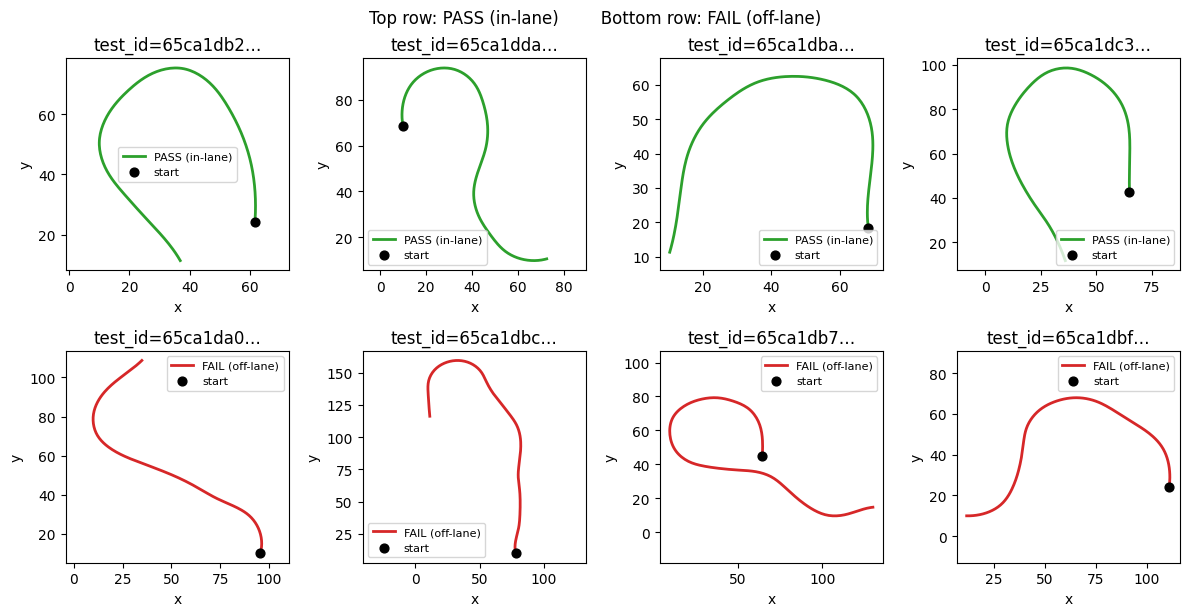

train_oracles : 122/319 failing (38.2%)
local val     : 31/96 failing  (32.3%)
test_suite    : 637 cases — labels held by the evaluator
road points per test case: 197–197


In [3]:
import matplotlib.pyplot as plt

passing = [e for e in train_oracles if not e.has_failed][:4]
failing = [e for e in train_oracles if e.has_failed][:4]

fig = plot_roads_grid(passing + failing, n_cols=4)
fig.suptitle("Top row: PASS (in-lane)        Bottom row: FAIL (off-lane)", fontsize=12, y=1.02)
plt.show()

# Descriptive stats — using only the labels you actually have (training data).
n_fail_train = sum(1 for e in train_oracles if e.has_failed)
n_fail_val   = sum(1 for v in val_ground_truth.values() if v["has_failed"])
rp_counts    = [len(e.test_case.road_points) for e in train_oracles]
print(f"train_oracles : {n_fail_train}/{len(train_oracles)} failing ({n_fail_train/len(train_oracles):.1%})")
print(f"local val     : {n_fail_val}/{len(val_suite)} failing  ({n_fail_val/len(val_suite):.1%})")
print(f"test_suite    : {len(test_suite)} cases — labels held by the evaluator")
print(f"road points per test case: {min(rp_counts)}–{max(rp_counts)}")

## 3. Baselines

Two trivial prioritizers to compare against, scored on your **local validation split**:

- **RandomPrioritizer** — shuffles the test suite. This is the official sample tool that ships with the ICST competition repo. Expected `APFD ≈ 0.5`.
- **IdentityPrioritizer** — keeps the test suite in its original order. Also expected near 0.5 because the order is already arbitrary.

**Any worthwhile heuristic should beat 0.5.** (Local APFD is noisier than the hidden test set because the validation split is small — treat it as a guide, not the final word.)

=== Evaluation report: RandomPrioritizer ===
  test suite size      : 96
  failing tests in suite: 31
  APFD                 : 0.5321   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.5430
  Time-to-first-fault  : 5.0 s
  Time-to-last-fault   : 96.0 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.0 ms

=== Evaluation report: IdentityPrioritizer ===
  test suite size      : 96
  failing tests in suite: 31
  APFD                 : 0.4313   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.4422
  Time-to-first-fault  : 2.0 s
  Time-to-last-fault   : 96.0 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.0 ms


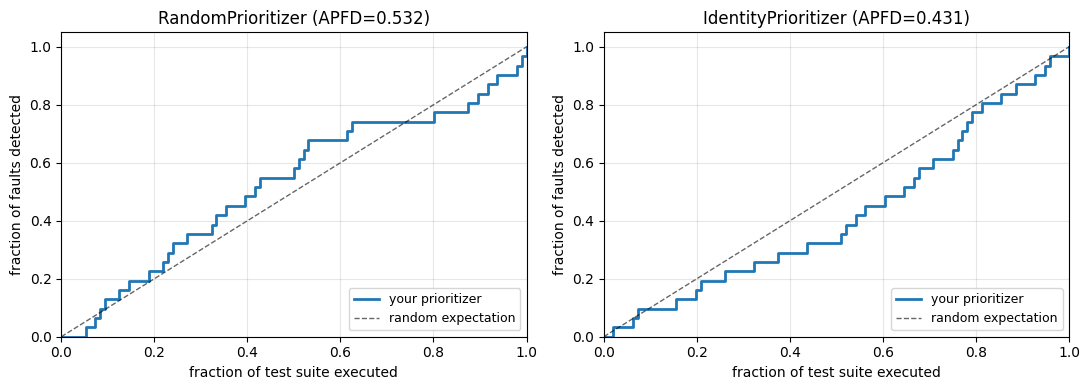

In [4]:
report_random   = evaluate(RandomPrioritizer(seed=0), dev_oracles, val_suite, val_ground_truth)
report_identity = evaluate(IdentityPrioritizer(),     dev_oracles, val_suite, val_ground_truth)

print(report_random)
print()
print(report_identity)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_fault_detection_curve(report_random.failed_positions,   report_random.n_tests,
                           title=f"RandomPrioritizer (APFD={report_random.apfd:.3f})",   ax=axes[0])
plot_fault_detection_curve(report_identity.failed_positions, report_identity.n_tests,
                           title=f"IdentityPrioritizer (APFD={report_identity.apfd:.3f})", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Your turn — implement `MyPrioritizer`

Fill in the two methods below.

### Required interface
```python
class MyPrioritizer:
    def initialize(self, oracles: list[OracleEntry]) -> None:
        # (optional) learn from training data here.
        # `oracles` is a list of (SDCTestCase, has_failed) pairs.
        ...

    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        # MUST return the test_ids in priority order — a permutation of the input ids.
        # The earlier a failing test appears in this list, the higher your APFD.
        ...
```

### Validity rules (enforced by the evaluator)
1. Every `test_id` in `test_suite` must appear **exactly once** in your output.
2. No unknown ids, no duplicates, no missing ids.

### Ideas to try (from simplest to most ambitious)
- **Sort by total road length** — longer roads have more chances to go off-lane.
- **Sort by total curvature** — sharper turns tend to push the car off-lane.
- **Sort by maximum local turn angle** — even one tight corner can cause failure.
- **Train a classifier** on `train_oracles` (sklearn `RandomForestClassifier` etc.) using engineered features per road, then sort the test suite by predicted failure probability.
- **Combine signals** — e.g., weight curvature × length.

> 💡 If you don't want to compute road features from scratch, an **unofficial** `sdc_lib.features` module ships a handful of quick approximations (length, turn angles, sharp-turn count, bounding box area). See Section 6 for the disclaimer and a worked example using it.

The skeleton below ships with a trivial identity ordering so the notebook runs end-to-end out of the box. Replace it with your own logic.

In [5]:
from sdc_lib import SDCTestCase, OracleEntry


class MyPrioritizer:
    """My SDC test prioritizer — fill in `prioritize` (and optionally `initialize`)."""

    def initialize(self, oracles: list[OracleEntry]) -> None:
        # OPTIONAL: learn something from the labelled training data.
        # Example (commented):
        #   self.avg_fail_len = sum(len(e.test_case.road_points) for e in oracles if e.has_failed) / ...
        pass

    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        # TODO: replace this trivial ordering with your own ranking logic.
        return [tc.test_id for tc in test_suite]

## 5. Run your prioritizer

Run this cell after every change. The APFD here is your **local estimate** on the validation split — try to push it above 0.6, then above 0.7. Your official APFD is computed by the evaluator on the hidden test set when you submit (Section 7).

> ℹ️ On the local split, `sim_time` is unknown (held by the evaluator), so APFDC and time-to-fault are placeholders — focus on **APFD**.

=== Evaluation report: MyPrioritizer ===
  test suite size      : 96
  failing tests in suite: 31
  APFD                 : 0.4313   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.4422
  Time-to-first-fault  : 2.0 s
  Time-to-last-fault   : 96.0 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.0 ms


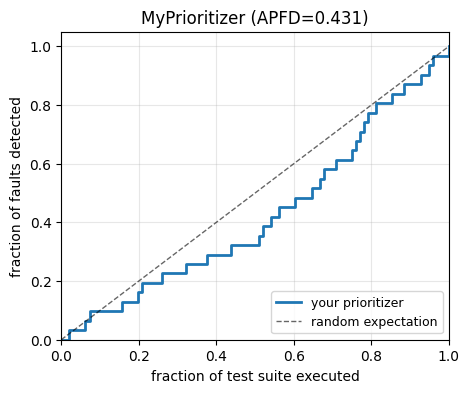

In [6]:
my_report = evaluate(MyPrioritizer(), dev_oracles, val_suite, val_ground_truth, tool_name="MyPrioritizer")
print(my_report)

plot_fault_detection_curve(
    my_report.failed_positions, my_report.n_tests,
    title=f"MyPrioritizer (APFD={my_report.apfd:.3f})",
)
plt.show()

### 5.1 Inspect what your prioritizer ranked at the top

Pull the test cases your prioritizer put first and draw their road shapes — useful for debugging.
If your top picks turn out to be **PASS (green)** roads, your ranking signal is misaligned with what actually fails.

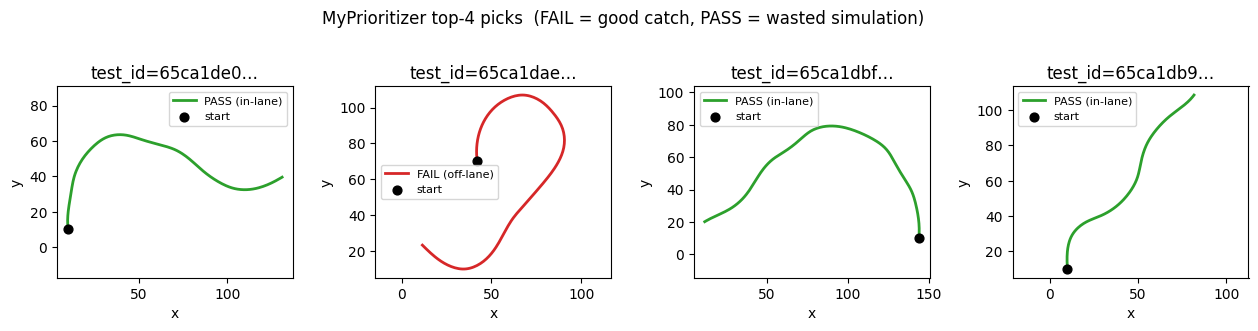

In [7]:
# Inspect MyPrioritizer's top picks (on the local validation split).
# Swap the first argument to inspect a different report
# (e.g. report_length, report_random, report_identity).
plot_top_picks(my_report, val_suite, val_ground_truth, k=4)
plt.show()

## 6. Optional helpers + worked example

The `sdc_lib.features` module ships a handful of helper functions for computing geometric features from a road:

```python
from sdc_lib.features import (
    total_length,        # Euclidean length of the polyline
    mean_turn_angle,     # average absolute turn angle (radians)
    max_turn_angle,      # largest single turn angle (radians)
    total_turn_angle,    # sum of absolute turn angles — crude 'total curvature'
    num_sharp_turns,     # count of turns exceeding a threshold (default 10°)
    bounding_box_area,   # area of axis-aligned bounding box
)
```

> ⚠️ **Disclaimer — this module is UNOFFICIAL support.**
>
> It is **not** part of the ICST/SBFT competition. The values these helpers return are **quick approximations**, not exact geometric quantities — they are sensitive to road sampling density, use unsigned angles, ignore rotation in the bounding box, and so on. Treat them as a low-friction starting point: **for stronger signal, implement your own (smarter, more accurate) versions.**

### Helper output on a single test case

To get a feel for what each helper produces, the cell below picks one road and runs every helper on it — printing the value next to a 2D plot of the road.

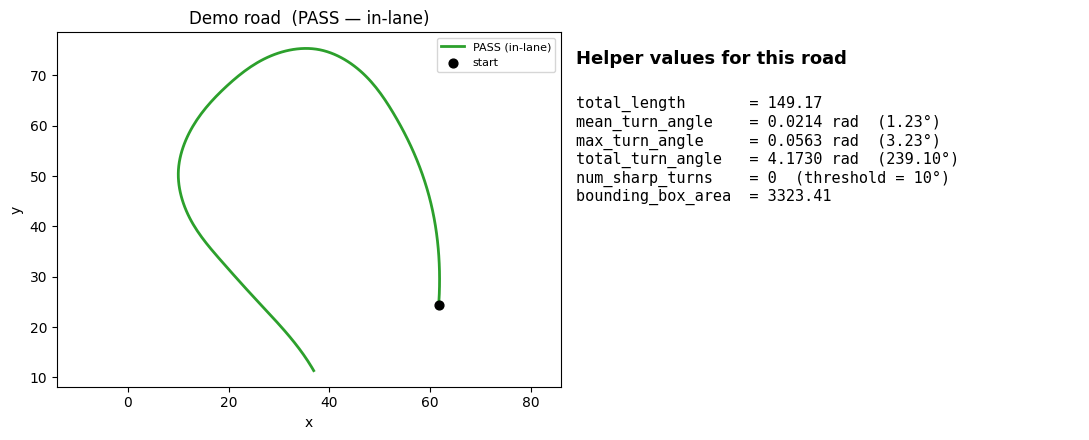

In [8]:
from sdc_lib.features import (
    total_length, mean_turn_angle, max_turn_angle,
    total_turn_angle, num_sharp_turns, bounding_box_area,
)
import math

# Pick a single test case to demo every helper on.
demo_entry = train_oracles[0]
tc = demo_entry.test_case
rp = tc.road_points

values = {
    "total_length":      f"{total_length(rp):.2f}",
    "mean_turn_angle":   f"{mean_turn_angle(rp):.4f} rad  ({math.degrees(mean_turn_angle(rp)):.2f}°)",
    "max_turn_angle":    f"{max_turn_angle(rp):.4f} rad  ({math.degrees(max_turn_angle(rp)):.2f}°)",
    "total_turn_angle":  f"{total_turn_angle(rp):.4f} rad  ({math.degrees(total_turn_angle(rp)):.2f}°)",
    "num_sharp_turns":   f"{num_sharp_turns(rp)}  (threshold = 10°)",
    "bounding_box_area": f"{bounding_box_area(rp):.2f}",
}

# Side-by-side: road shape on the left, helper values on the right.
fig, (ax_road, ax_text) = plt.subplots(1, 2, figsize=(11, 4.5))
plot_road(tc, has_failed=demo_entry.has_failed, ax=ax_road)
ax_road.set_title(
    f"Demo road  ({'FAIL — off-lane' if demo_entry.has_failed else 'PASS — in-lane'})"
)

ax_text.axis("off")
ax_text.text(0.0, 0.95, "Helper values for this road",
             fontsize=13, fontweight="bold", va="top", transform=ax_text.transAxes)
ax_text.text(0.0, 0.82,
             "\n".join(f"{k:<18} = {v}" for k, v in values.items()),
             fontsize=11, family="monospace", va="top", transform=ax_text.transAxes)

fig.tight_layout(); plt.show()

### Worked example: what if we sort by `total_length` only?

The simplest possible heuristic — pick one helper, sort the test suite by it. Longer roads have more chance to drift off-lane, so we try **longest first**.

=== Evaluation report: LengthPrioritizer ===
  test suite size      : 96
  failing tests in suite: 31
  APFD                 : 0.6198   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.6307
  Time-to-first-fault  : 2.0 s
  Time-to-last-fault   : 93.0 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 4.1 ms


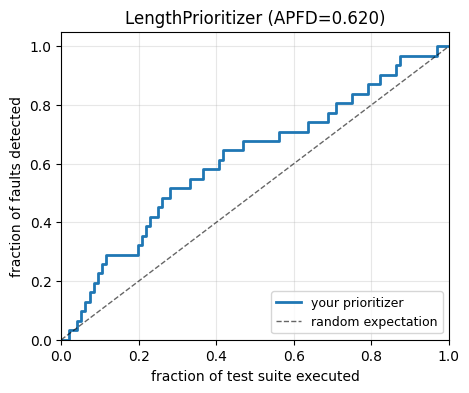

In [9]:
from sdc_lib.features import total_length


class LengthPrioritizer:
    """Sort by `total_length` only — longest road first."""

    def initialize(self, oracles): pass

    def prioritize(self, test_suite):
        ranked = sorted(test_suite, key=lambda tc: -total_length(tc.road_points))
        return [tc.test_id for tc in ranked]


report_length = evaluate(LengthPrioritizer(), dev_oracles, val_suite, val_ground_truth)
print(report_length)
plot_fault_detection_curve(
    report_length.failed_positions, report_length.n_tests,
    title=f"LengthPrioritizer (APFD={report_length.apfd:.3f})",
)
plt.show()

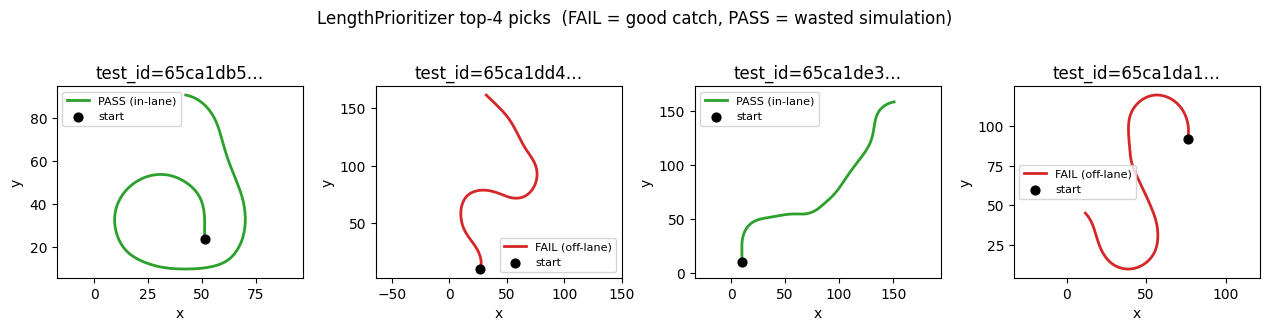

In [10]:
# Inspect LengthPrioritizer's top picks (the worked example above, on the local split).
plot_top_picks(report_length, val_suite, val_ground_truth, k=4)
plt.show()

### Worked example #2: a prioritizer that *learns* in `initialize()`

`LengthPrioritizer` above has an **empty `initialize()`** (`pass`) — it ignores the training labels entirely and only sorts by a fixed geometric feature.

`CurvaturePrioritizer` below shows the other half of the interface: it **uses `initialize()` to learn something from the labelled training data**, then uses that learned knowledge in `prioritize()`. Concretely, `initialize()` computes the *average curvature of the failing roads* and stores it on `self`; `prioritize()` then ranks the (unlabelled) test cases by how close their curvature is to that learned "failure profile."

Both methods stay ~2 lines. Run the cell and compare the two APFDs side by side — this is the smallest possible example of the `initialize()` → `prioritize()` workflow your `MyPrioritizer` should follow.

LengthPrioritizer    (initialize does nothing)  APFD = 0.620
CurvaturePrioritizer (initialize learns a value) APFD = 0.399


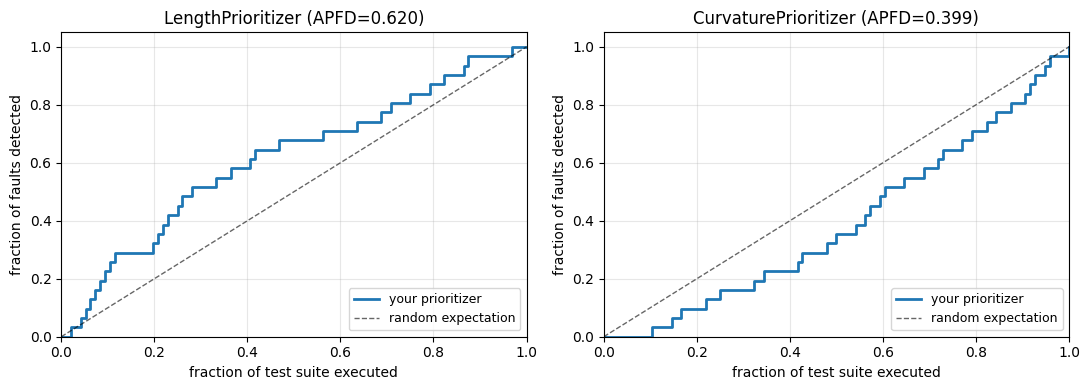

In [11]:
from sdc_lib.features import total_turn_angle


class CurvaturePrioritizer:
    """Uses `initialize()` to LEARN, then ranks in `prioritize()`.

    initialize(): measure the average curvature of the FAILING training roads
                  and remember it (this is the "knowledge" learned from labels).
    prioritize(): rank test cases by how close their curvature is to that
                  learned failing-road profile — closest first.
    """

    def initialize(self, oracles):
        fails = [total_turn_angle(e.test_case.road_points) for e in oracles if e.has_failed]
        self.fail_curve = sum(fails) / len(fails)        # ← learned from training labels

    def prioritize(self, test_suite):
        ranked = sorted(test_suite, key=lambda tc: abs(total_turn_angle(tc.road_points) - self.fail_curve))
        return [tc.test_id for tc in ranked]


# Compare the two worked examples on the local validation split.
report_curve = evaluate(CurvaturePrioritizer(), dev_oracles, val_suite, val_ground_truth,
                        tool_name="CurvaturePrioritizer")

print(f"LengthPrioritizer    (initialize does nothing)  APFD = {report_length.apfd:.3f}")
print(f"CurvaturePrioritizer (initialize learns a value) APFD = {report_curve.apfd:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_fault_detection_curve(report_length.failed_positions, report_length.n_tests,
                           title=f"LengthPrioritizer (APFD={report_length.apfd:.3f})", ax=axes[0])
plot_fault_detection_curve(report_curve.failed_positions, report_curve.n_tests,
                           title=f"CurvaturePrioritizer (APFD={report_curve.apfd:.3f})", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Submission

Your local APFD (Sections 5–6) is only an **estimate** on the validation split. Your official score is computed by the evaluator on the **hidden test set** using labels you don't have.

To submit:

1. Make sure the **Section 5** cell runs cleanly — no `PrioritizationError`.
2. Run the **submission check** cell below: it trains `MyPrioritizer` on all labelled data and confirms it returns a valid ordering of every hidden `test_suite` case.
3. **Email your `MyPrioritizer` class** (the whole class from Section 4) to your instructor.
4. Add a short markdown cell explaining your approach in 2–3 sentences.

The evaluator runs your class against the hidden labels and reports your **APFD** (the official ranking metric) and your **rank** on the leaderboard. See `../1_challenge_guide.md` for the full rules.

In [12]:
# --- Submission check -------------------------------------------------
# Runs your prioritizer on the real (hidden-label) test_suite and confirms the
# output is a valid permutation of every hidden test id. It does NOT show an APFD —
# you don't have the labels; that is what the evaluator computes.

submission = MyPrioritizer()
submission.initialize(train_oracles)          # for the real run, train on ALL labelled data
order = list(submission.prioritize(test_suite))

expected = {tc.test_id for tc in test_suite}
assert len(order) == len(set(order)), "❌ duplicate test ids in your output"
assert set(order) == expected, "❌ your output has missing ids or unknown ids"
print(f"✅ Valid submission: {len(order)} test ids — no duplicates, none missing, no unknowns.")
print("Now email your `MyPrioritizer` class (Section 4) to your instructor for scoring.")

✅ Valid submission: 637 test ids — no duplicates, none missing, no unknowns.
Now email your `MyPrioritizer` class (Section 4) to your instructor for scoring.


## 8. (부록) LLM으로 `MyPrioritizer` 자동 생성하기 — 프롬프트 템플릿

`MyPrioritizer`를 직접 코딩하지 않아도 됩니다. **아래 셀 전체를 복사**해서 LLM(Claude, ChatGPT 등)에 붙여넣고, 맨 끝의 **`# 내가 원하는 우선순위 방식`** 부분만 본인이 구현하고 싶은 논리로 한국어로 바꿔 쓰세요. LLM이 문법에 맞는 `MyPrioritizer` 클래스를 만들어 줍니다. 받은 클래스를 **Section 4** 셀에 붙여넣고 **Section 5**로 검증한 뒤 제출하세요.

---

# 역할
너는 Python 전문가다. 자율주행차(SDC) 테스트 **우선순위 결정기(prioritizer)** 클래스를 작성해야 한다. 아래 사양을 정확히 지켜, 곧바로 실행 가능한 `MyPrioritizer` 클래스 **하나만** 출력해라. 설명 문장 없이 코드만 출력해라.

# 배경 / 목표
- 시뮬레이터 기반 주행 테스트들의 **실행 순서**를 정하는 문제다.
- 목표: **실패하는 테스트(차가 차선 이탈)가 가능한 한 앞쪽에 오도록** 정렬한다. 실패를 빨리 찾을수록 점수(APFD)가 높다.
- 채점기는 내가 반환한 순서를 **숨겨진 정답 라벨**로 평가한다. 내 코드(`prioritize`)는 정답 라벨을 받지 못한다.

# 필수 인터페이스 (이 시그니처를 정확히 따른다)
```python
class MyPrioritizer:
    def initialize(self, oracles: list[OracleEntry]) -> None:
        # (선택) 라벨 있는 학습 데이터로 학습/통계 계산. 결과는 self에 저장.
        ...
    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        # 라벨 없는 test_suite를 받아, test_id들을 '우선순위 순서'로 반환한다.
        ...
```

# 데이터 구조
- `OracleEntry` (학습용, 라벨 포함 — `initialize`의 `oracles`에서만 접근 가능):
  - `.test_case`  : `SDCTestCase`
  - `.has_failed` : `bool`   ← 라벨 (실패 = True)
- `SDCTestCase` (테스트 케이스):
  - `.test_id`     : `str`
  - `.road_points` : `list[tuple[float, float]]`   ← 도로를 이루는 (x, y) 점들의 순서열
- 주의: `prioritize`가 받는 `test_suite`의 원소에는 `.has_failed`가 **없다** (라벨 숨김). `initialize`에서 받은 `oracles`에만 라벨이 있다.

# 사용 가능한 import (이미 제공됨)
```python
from sdc_lib import SDCTestCase, OracleEntry
from sdc_lib.features import (
    total_length,        # 도로 폴리라인의 유클리드 길이
    mean_turn_angle,     # 평균 절대 회전각 (radian)
    max_turn_angle,      # 최대 단일 회전각 (radian)
    total_turn_angle,    # 절대 회전각의 합 — 대략적 '총 곡률'
    num_sharp_turns,     # 임계값(기본 10°) 초과 회전 개수
    bounding_box_area,   # 축 정렬 bounding box 넓이
)
```
필요하면 `road_points`로부터 직접 새 feature를 계산해도 된다 (위 helper는 근사값이다).

# 유효성 규칙 (채점기가 강제하므로 반드시 지킬 것)
1. 출력 리스트는 `test_suite`의 모든 `test_id`를 **정확히 한 번씩** 포함해야 한다.
2. 모르는 id·중복 id·누락 id가 있으면 안 된다 (= 입력 id들의 **순열**이어야 한다).

# 스타일 예시 (이 형식과 문법을 그대로 따른다)

예시 A — `initialize`를 쓰지 않고 고정 feature로 정렬:
```python
from sdc_lib.features import total_length

class LengthPrioritizer:
    def initialize(self, oracles): pass
    def prioritize(self, test_suite):
        ranked = sorted(test_suite, key=lambda tc: -total_length(tc.road_points))
        return [tc.test_id for tc in ranked]
```

예시 B — `initialize`에서 라벨(실패 경험)로 학습한 값을 사용:
```python
from sdc_lib.features import total_turn_angle

class CurvaturePrioritizer:
    def initialize(self, oracles):
        fails = [total_turn_angle(e.test_case.road_points) for e in oracles if e.has_failed]
        self.fail_curve = sum(fails) / len(fails)            # 실패 도로들의 평균 곡률을 학습
    def prioritize(self, test_suite):
        ranked = sorted(test_suite, key=lambda tc: abs(total_turn_angle(tc.road_points) - self.fail_curve))
        return [tc.test_id for tc in ranked]
```

# 출력 형식
- 클래스 이름은 반드시 **`MyPrioritizer`** 로 한다.
- 필요한 `import`를 클래스 정의 위에 포함한다.
- Section 4 셀에 그대로 붙여넣어 실행되도록 **`MyPrioritizer` 클래스 정의만** 출력한다 (그 외 설명/마크다운 금지).
- 빈 리스트, 0으로 나누기, 실패 케이스가 0개인 경우 등에서도 죽지 않도록 **방어 코드**를 넣는다.

# 내가 원하는 우선순위 방식
(여기에 한국어로 본인 논리를 설명하세요. 아래는 예시 — 본인 것으로 교체)

> `initialize`에서 학습 데이터의 **실패한 도로들(`has_failed == True`)의 평균 길이**를 구해서 저장해줘 (실패 도로가 대략 어느 정도 길이인지 감을 잡는 거야). 그리고 `prioritize`에서는 각 테스트 케이스의 길이가 그 "실패 평균 길이"에 **가까운 순서대로** 정렬해줘 — 실패 도로와 비슷한 길이의 케이스를 먼저 실행해 보자는 단순한 아이디어야.

# 위 프롬프트 예시의 ChatGPT 생성 결과

In [16]:
class MyPrioritizer:
    def initialize(self, oracles: list[OracleEntry]) -> None:
        fail_lengths = []
        for entry in oracles:
            try:
                if entry.has_failed:
                    fail_lengths.append(total_length(entry.test_case.road_points))
            except Exception:
                pass

        if fail_lengths:
            self.fail_mean_length = sum(fail_lengths) / len(fail_lengths)
        else:
            self.fail_mean_length = 0.0

    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        target_length = getattr(self, "fail_mean_length", 0.0)

        ranked = sorted(
            test_suite,
            key=lambda tc: (
                abs(total_length(tc.road_points) - target_length),
                tc.test_id,
            ),
        )

        return [tc.test_id for tc in ranked]

=== Evaluation report: MyPrioritizer ===
  test suite size      : 96
  failing tests in suite: 31
  APFD                 : 0.4585   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.4694
  Time-to-first-fault  : 2.0 s
  Time-to-last-fault   : 93.0 s
  initialize() runtime : 4.8 ms
  prioritize() runtime : 4.6 ms


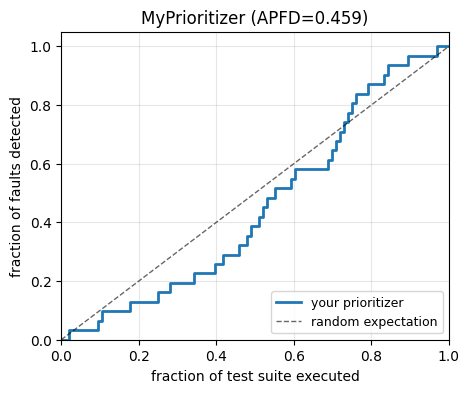

In [17]:
my_report = evaluate(MyPrioritizer(), dev_oracles, val_suite, val_ground_truth, tool_name="MyPrioritizer")
print(my_report)

plot_fault_detection_curve(
    my_report.failed_positions, my_report.n_tests,
    title=f"MyPrioritizer (APFD={my_report.apfd:.3f})",
)
plt.show()

In [18]:
# --- Submission check -------------------------------------------------
# Runs your prioritizer on the real (hidden-label) test_suite and confirms the
# output is a valid permutation of every hidden test id. It does NOT show an APFD —
# you don't have the labels; that is what the evaluator computes.

submission = MyPrioritizer()
submission.initialize(train_oracles)          # for the real run, train on ALL labelled data
order = list(submission.prioritize(test_suite))

expected = {tc.test_id for tc in test_suite}
assert len(order) == len(set(order)), "❌ duplicate test ids in your output"
assert set(order) == expected, "❌ your output has missing ids or unknown ids"
print(f"✅ Valid submission: {len(order)} test ids — no duplicates, none missing, no unknowns.")
print("Now email your `MyPrioritizer` class (Section 4) to your instructor for scoring.")

✅ Valid submission: 637 test ids — no duplicates, none missing, no unknowns.
Now email your `MyPrioritizer` class (Section 4) to your instructor for scoring.
